In [1]:
pip install quandl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import quandl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.api as sm # Using .api imports the public access version of statsmodels, which is a library that handles 
# statistical models.
import os
import warnings # This is a library that handles warnings.

warnings.filterwarnings("ignore") # Disable deprecation warnings that could indicate, for instance, a suspended library or 
# feature. These are more relevant to developers and very seldom to analysts.

plt.style.use('fivethirtyeight') # This is a styling option for how your plots will appear. More examples here:
# https://matplotlib.org/3.2.1/tutorials/introductory/customizing.html
# https://matplotlib.org/3.1.0/gallery/style_sheets/fivethirtyeight.html

In [3]:
# determine path folder
path = r'C:\Users\johan\Documents\Indonesia Integrated Seismic Risk Analysis' 

path

print(path)

# Read file CSV 

df = pd.read_csv(os.path.join(path, '02 Data', 'Prepared Data', 'katalog_gempa_cleaned.csv'))

C:\Users\johan\Documents\Indonesia Integrated Seismic Risk Analysis


In [4]:
df.head()

,Date,Time,Latitude,Longitude,Depth,Magnitude,Location,Full_DateTime,Time_in_seconds,Year,Month,Magnitude_Category
0,2008-11-01,02:43.1,-9.18,119.06,10,4.9,Sumba Region - Indonesia,2008-11-01 00:02:43.100,163.1,2008,11,Moderate (4-6)
1,2008-11-01,58:50.2,-6.55,129.64,10,4.6,Banda Sea,2008-11-01 00:58:50.200,3530.2,2008,11,Moderate (4-6)
2,2008-11-01,43:12.9,-7.01,106.63,121,3.7,Java - Indonesia,2008-11-01 00:43:12.900,2592.9,2008,11,Minor (2-4)
3,2008-11-01,24:14.8,-3.30,127.85,10,3.2,Seram - Indonesia,2008-11-01 00:24:14.800,1454.8,2008,11,Minor (2-4)
4,2008-11-01,20:37.3,-6.41,129.54,70,4.3,Banda Sea,2008-11-01 00:20:37.300,1237.3,2008,11,Moderate (4-6)


In [5]:
df.dtypes

Date                   object
Time                   object
Latitude              float64
Longitude             float64
Depth                   int64
Magnitude             float64
Location               object
Full_DateTime          object
Time_in_seconds       float64
Year                    int64
Month                   int64
Magnitude_Category     object
dtype: object

In [6]:
# Convert the Full_DateTime column from object/string to actual datetime format.
df['Full_DateTime'] = pd.to_datetime(df['Full_DateTime'])

# Check the data type again; it should now be datetime64[ns].
print(df['Full_DateTime'].dtypes)

datetime64[ns]


In [7]:
# 1. We create a new dataframe called 'data_ts'
# We count the number of earthquakes based on Full_DateTime per month ('M')
data_ts = df.resample('M', on='Full_DateTime').count()

# 2. We only need one column of calculation results.
# We'll only take the 'Magnitude' column (which now contains the number of earthquakes per month).
data_ts = data_ts[['Magnitude']]

# 3. Rename the columns to match the assignment standards (Value)
data_ts.rename(columns={'Magnitude': 'Value'}, inplace=True)

# Check the results
data_ts.head()

,Value
Full_DateTime,
2008-11-30,183
2008-12-31,133
2009-01-31,251
2009-02-28,350
2009-03-31,301


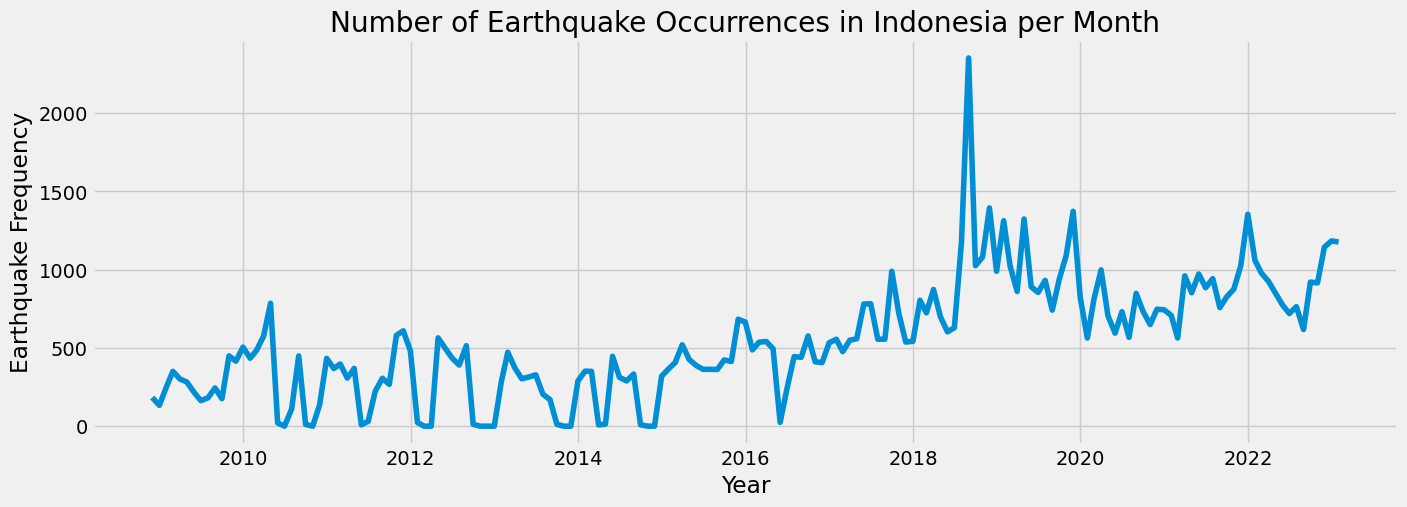

In [8]:
plt.figure(figsize=(15,5))
plt.plot(data_ts)
plt.title('Number of Earthquake Occurrences in Indonesia per Month')
plt.xlabel('Year')
plt.ylabel('Earthquake Frequency')
plt.show()

#### Resampling Data (Transforming Events into Time Trends)

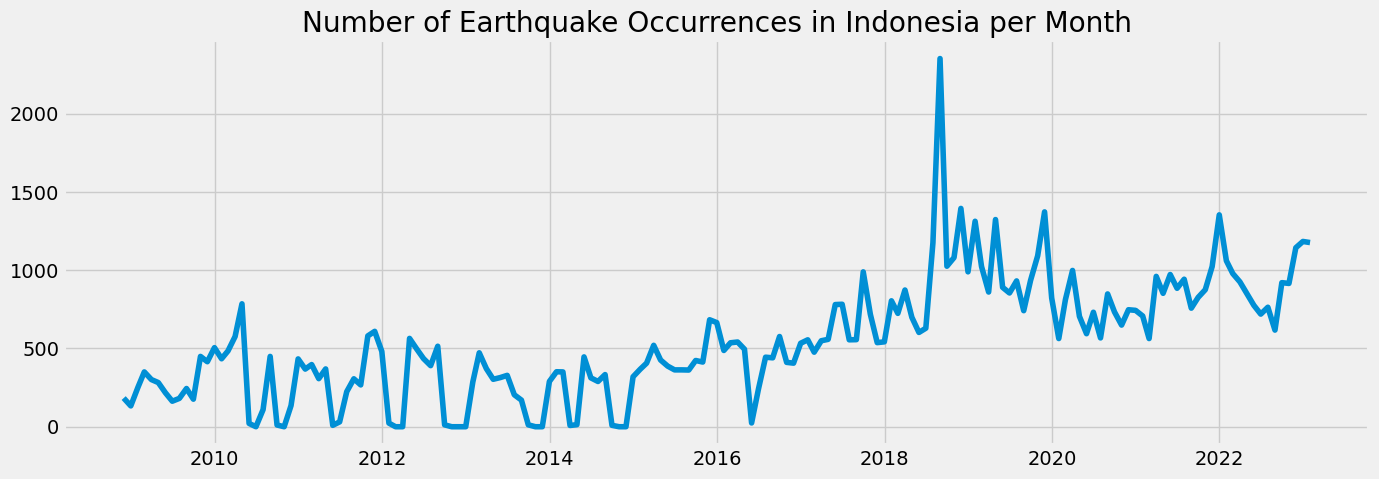

In [9]:
# 1. Resampling: Calculating the number of earthquake occurrences per month ('M')
data_ts = df.resample('M', on='Full_DateTime').count()

# 2. We'll take the 'Magnitude' column as a representation of the quantity, then rename it to 'Value'.
data_ts = data_ts[['Magnitude']]
data_ts.rename(columns={'Magnitude': 'Value'}, inplace=True)

# 3. Check the initial visualization.
plt.figure(figsize=(15,5))
plt.plot(data_ts)
plt.title('Number of Earthquake Occurrences in Indonesia per Month')
plt.show()

#### Time Series Decomposition (Step 5)

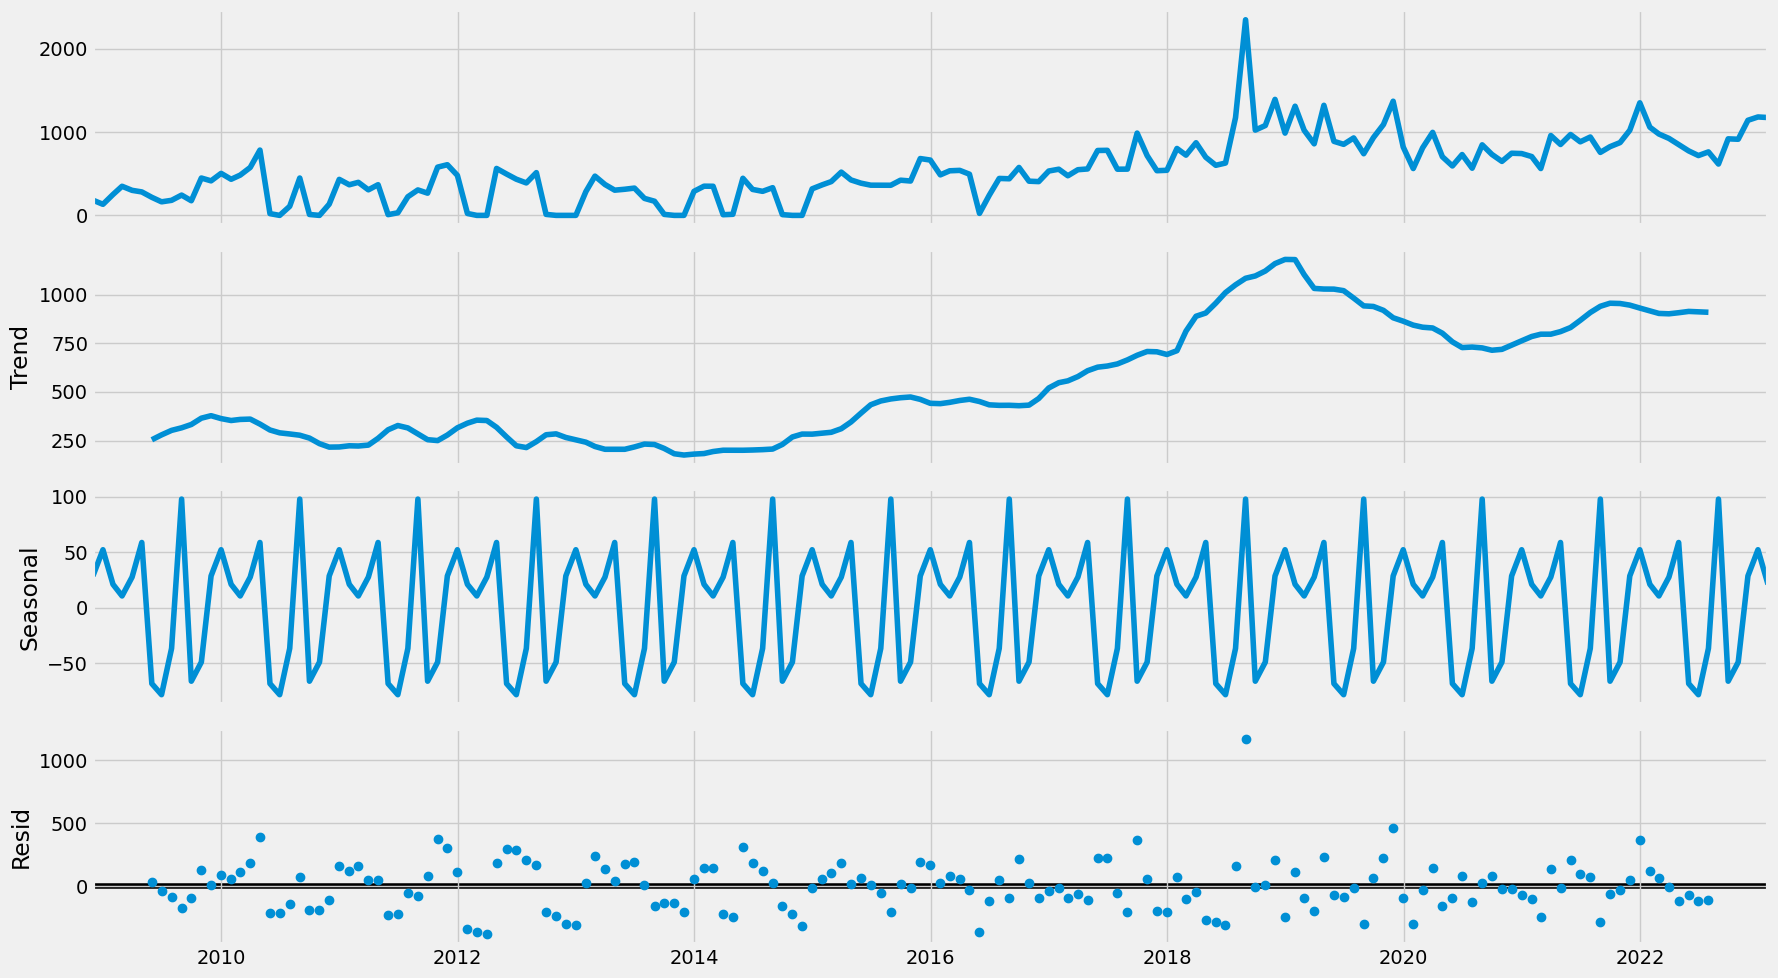

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform decomposition
# We use the 'additive' model
decomposition = seasonal_decompose(data_ts, model='additive')

# Plotting decomposition result
from pylab import rcParams
rcParams['figure.figsize'] = 18, 10
decomposition.plot()
plt.show()

Based on the decomposition graph, the Trend component shows whether the frequency of seismic activity in Indonesia is increasing or decreasing in the long term. The Seasonal component shows recurring patterns (if any), but in earthquake activity, this pattern usually does not have strong scientific significance compared to economic data.

#### Dickey-Fuller Test

In [11]:
from statsmodels.tsa.stattools import adfuller

def dickey_fuller_test(timeseries):
    print('Result Dickey-Fuller Test:')
    test = adfuller(timeseries, autolag='AIC')
    result = pd.Series(test[0:4], index=['Test Statistic','p-value','Number of Lags Used','Number of Observations Used'])
    for key,value in test[4].items():
       result['Critical Value (%s)'%key] = value
    print(result)

# Run the test on data_ts.
dickey_fuller_test(data_ts['Value'])

Result Dickey-Fuller Test:
Test Statistic                  -1.130464
p-value                          0.702771
Number of Lags Used              7.000000
Number of Observations Used    163.000000
Critical Value (1%)             -3.471119
Critical Value (5%)             -2.879441
Critical Value (10%)            -2.576314
dtype: float64


Interpretation of Results (Markdown Cell for Your Task):

1. Look at the p-value: Your value is 0.702. The condition for data to be considered stationary is that the p-value must be less than 0.05. Since 0.702 is much greater than 0.05, your data is not statistically stationary.

2. Compare the Test Statistic with the Critical Values: Your Test Statistic: -1.13 Critical Value (5%): -2.87 For stationarity, the Test Statistic must be smaller (more negative) than the Critical Value. Since -1.13 is not smaller than -2.87, this reinforces the evidence that the data is not stationary.

3. Statistical Conclusion: You Failed to Reject the Null Hypothesis (H0). This means that your data still has a strong trend or seasonal pattern that needs to be removed.

Null Hypothesis (H0): "The data has a unit root, which means the data is NON-STATIONARY." This means: The pattern of your monthly earthquake counts still contains a trend or seasonality (it is unstable). The mean and variance change over time.

Alternative Hypothesis (H1): "The data does not have a unit root, which means the data is STATIONARY." This means: The pattern of earthquake counts is stable. There is no dominant trend, making it easier to predict (forecasting).
Conclusion Based on Your Results: Because the results you obtained were:

p-value: 0.702 (Greater than the significance level of 0.05)

Test Statistic: -1.13 (Not smaller/more negative than the Critical Value -2.87)

"Because the p-value (0.702) is greater than 0.05, I fail to reject the Null Hypothesis. This means that statistically, my monthly earthquake count data is Non-Stationary. Therefore, I need to perform a differencing process to remove the trend and make the data stationary before proceeding to autocorrelation analysis."

#### Differencing

In [12]:
from statsmodels.tsa.stattools import adfuller

# 1. Define the function first.
def stationarity_test(timeseries):
    print('Result Dickey-Fuller Test:')
    test = adfuller(timeseries, autolag='AIC')
    result = pd.Series(test[0:4], index=['Test Statistic','p-value','Number of Lags Used','Number of Observations Used'])
    for key,value in test[4].items():
       result['Critical Value (%s)'%key] = value
    print(result)

# 2. Perform differencing
data_diff = data_ts - data_ts.shift(1)
data_diff.dropna(inplace=True)

# 3. Run the function on the differenced data.
stationarity_test(data_diff['Value'])

Result Dickey-Fuller Test:
Test Statistic                -7.976881e+00
p-value                        2.687556e-12
Number of Lags Used            6.000000e+00
Number of Observations Used    1.630000e+02
Critical Value (1%)           -3.471119e+00
Critical Value (5%)           -2.879441e+00
Critical Value (10%)          -2.576314e+00
dtype: float64


nterpretation of Results (Write in Markdown Cell):

1. p-value: The value is  (or 0.00000000000268). This is much smaller than the 0.05 threshold.

2. Test Statistic: The value is -7.97, which is much smaller (more negative) than the 1% Critical Value (-3.47).

3. Conclusion: We successfully REJECT the Null Hypothesis (H0
). The monthly earthquake count data after the first differencing no longer has a unit root, meaning the data is now stationary.

#### Check Autocorrelations

<Figure size 1500x500 with 0 Axes>

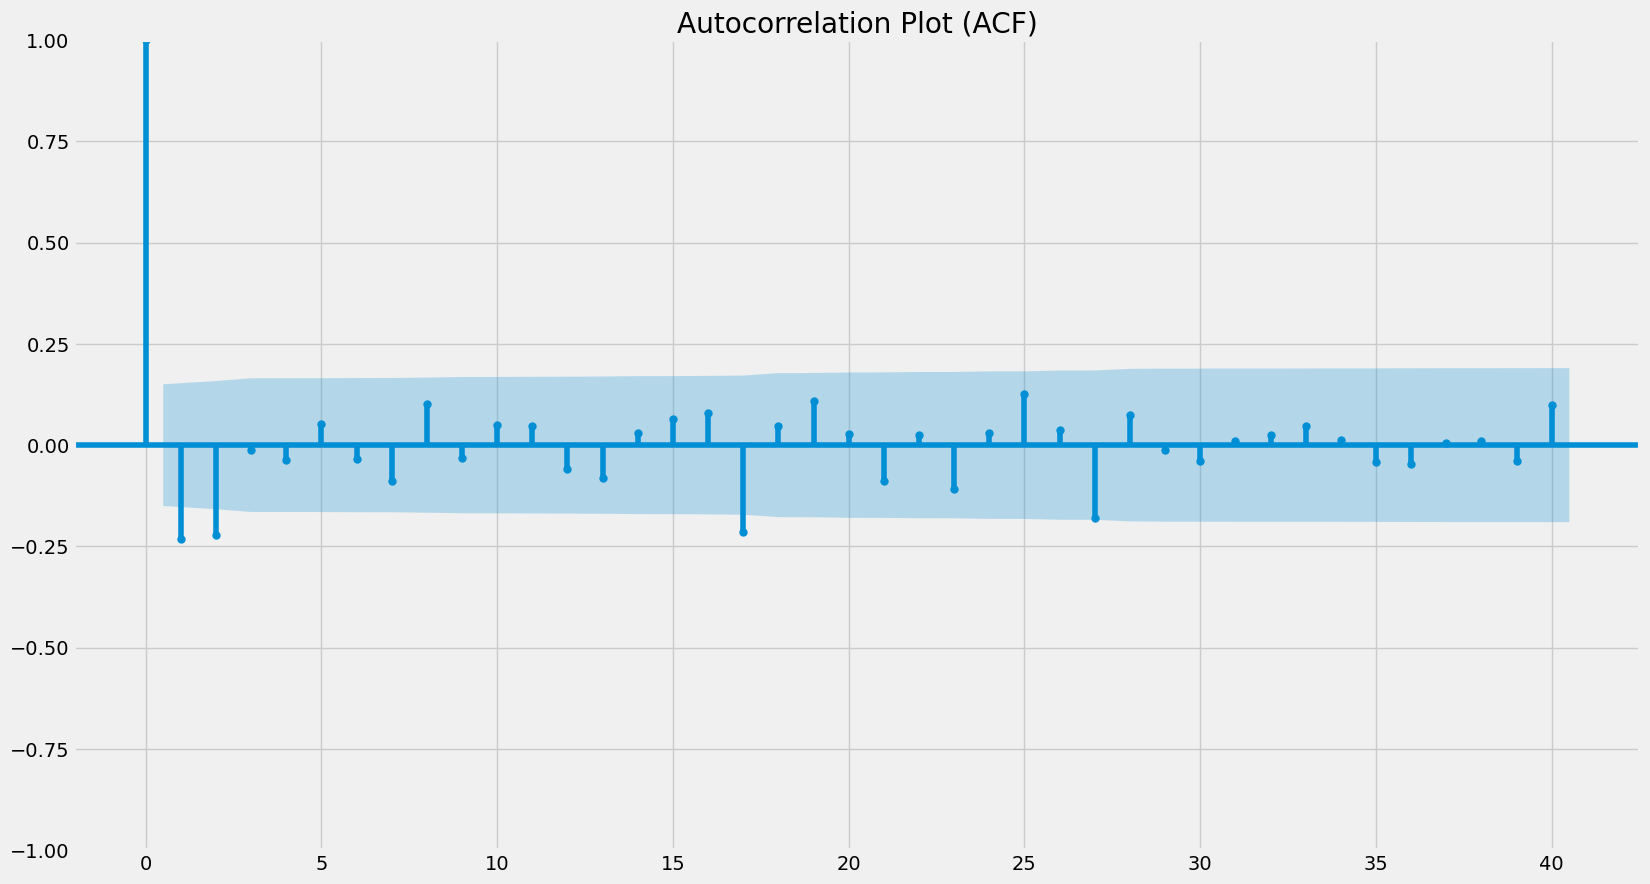

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Creating an Autocorrelation (ACF) plot
# We will use the differenced data (data_diff)
plt.figure(figsize=(15,5))
plot_acf(data_diff['Value'], lags=40)
plt.title('Autocorrelation Plot (ACF)')
plt.show()

Autocorrelation (ACF) Interpretation

Look at the bar graph (Lags) you just created:

- Lag 0:  This will definitely have a value of 1.0 (because it correlates the data with itself).

- Lines within the blue area: This indicates that the data on the number of earthquakes this month does not have a strong linear dependence on previous months.

- Analysis: If most of the lines are within the blue area (shadow), it means your earthquake data has become a "stationary series" that is free from disturbing past trends.

"This analysis proves that although earthquake activity in Indonesia appears fluctuating (non-stationary) in the raw data, through a single differencing process, the data is successfully stabilized statistically. This allows us to see the pure pattern of seismic activity without being disturbed by the increasing trend in the number of earthquake reports as sensor technology advances from year to year."